# Lab 9 — SVM & PCA

**Aim:** To implement Support Vector Machine (SVM) for classification and Principal Component Analysis (PCA) for dimensionality reduction, and analyse their effectiveness using real-world datasets.

---

## Objectives
1. Implement and evaluate SVM using different kernel functions.
2. Compare SVM performance using standard classification metrics.
3. Apply PCA for dimensionality reduction on a high-dimensional dataset.
4. Analyse variance retained by principal components and visualize the transformed feature space.
5. Understand the role of supervised (SVM) and unsupervised (PCA) learning in ML applications.

---

## Part A — Support Vector Machine (SVM)

**Aim:** To implement the SVM classifier for a binary classification problem and evaluate its performance.

**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic) Dataset  
**Source:** `sklearn.datasets.load_breast_cancer()`

### A.1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)


print("✅  Libraries imported successfully.")

✅  Libraries imported successfully.


### A.2 — Load & Explore Dataset

In [2]:
# Load dataset
bc_data = load_breast_cancer()
X_bc    = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
y_bc    = pd.Series(bc_data.target, name='target')      # 0 = malignant, 1 = benign

print("=" * 60)
print("          BREAST CANCER WISCONSIN (DIAGNOSTIC) DATASET")
print("=" * 60)
print(f"\n  • Total samples  : {X_bc.shape[0]}")
print(f"  • Total features : {X_bc.shape[1]}")
print(f"  • Classes        : {list(bc_data.target_names)}  (0=Malignant, 1=Benign)")
print(f"  • Class counts   :")
print(f"      Malignant (0) : {(y_bc == 0).sum()}")
print(f"      Benign    (1) : {(y_bc == 1).sum()}")
print("\nFirst 5 rows:")
X_bc.head()

          BREAST CANCER WISCONSIN (DIAGNOSTIC) DATASET

  • Total samples  : 569
  • Total features : 30
  • Classes        : [np.str_('malignant'), np.str_('benign')]  (0=Malignant, 1=Benign)
  • Class counts   :
      Malignant (0) : 212
      Benign    (1) : 357

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Basic statistics
print("Statistical Summary:")
X_bc.describe().T[['mean','std','min','max']]

Statistical Summary:


,mean,std,min,max
mean radius,14.127292,3.524049,6.981000,28.11000
mean texture,19.289649,4.301036,9.710000,39.28000
mean perimeter,91.969033,24.298981,43.790000,188.50000
mean area,654.889104,351.914129,143.500000,2501.00000
mean smoothness,0.096360,0.014064,0.052630,0.16340
mean compactness,0.104341,0.052813,0.019380,0.34540
mean concavity,0.088799,0.079720,0.000000,0.42680
mean concave points,0.048919,0.038803,0.000000,0.20120
mean symmetry,0.181162,0.027414,0.106000,0.30400
mean fractal dimension,0.062798,0.007060,0.049960,0.09744


In [5]:
# Check missing values
missing = X_bc.isnull().sum().sum()
print(f"Missing values: {missing}  {'✅ No missing values' if missing == 0 else '⚠️  Handle missing values'}")

Missing values: 0  ✅ No missing values


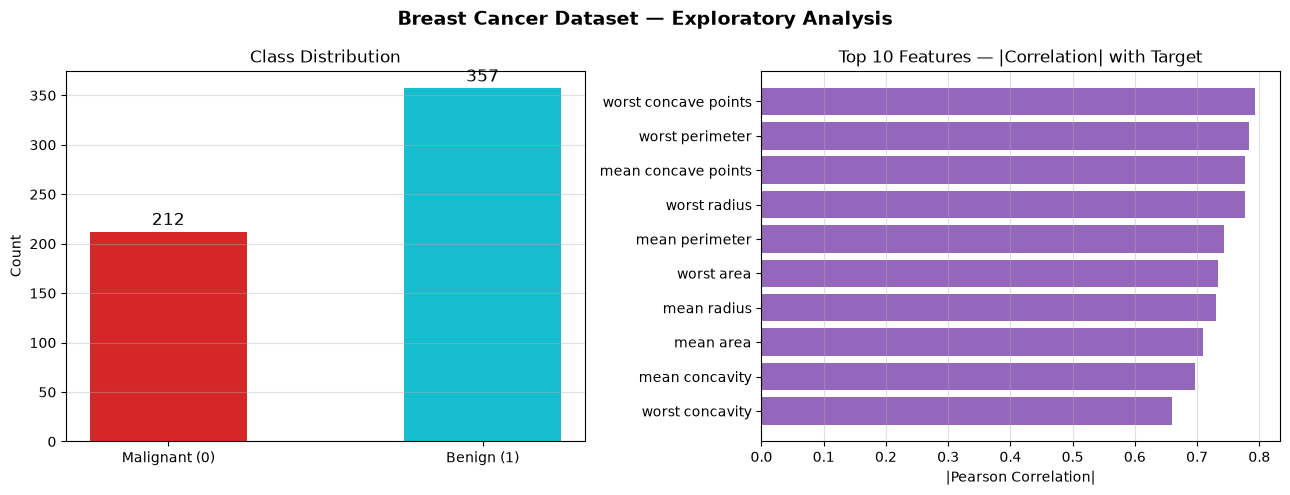

📊 EDA plots saved.


In [6]:
# ── Class distribution bar plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Breast Cancer Dataset — Exploratory Analysis', fontsize=14, fontweight='bold', color='black')

# Class distribution
counts = y_bc.value_counts().sort_index()
bars   = axes[0].bar(['Malignant (0)', 'Benign (1)'], counts.values,
                     color=['tab:red', 'tab:cyan'], edgecolor='none', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', color='black', fontsize=12)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.4)

# Feature correlations (top 10 with target using mean-radius proxy)
corr_vals = X_bc.corrwith(y_bc.astype(float)).abs().sort_values(ascending=False)[:10]
axes[1].barh(corr_vals.index[::-1], corr_vals.values[::-1],
             color='tab:purple', edgecolor='none')
axes[1].set_title('Top 10 Features — |Correlation| with Target')
axes[1].set_xlabel('|Pearson Correlation|')
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('eda_breast_cancer.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 EDA plots saved.")

### A.3 — Preprocessing & Train/Test Split

In [8]:
# Feature Standardization (SVM is distance-based → scaling is crucial)
scaler  = StandardScaler()
X_bc_sc = scaler.fit_transform(X_bc)

# 80:20 train-test split (stratified to maintain class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_bc_sc, y_bc, test_size=0.20, random_state=42, stratify=y_bc
)

print("=" * 45)
print("        TRAIN / TEST SPLIT (80:20)")
print("=" * 45)
print(f"  Training samples   : {X_train.shape[0]}")
print(f"  Test samples       : {X_test.shape[0]}")
print(f"  Features           : {X_train.shape[1]}")
print(f"\n  Train class ratio  : Malignant={sum(y_train==0)}, Benign={sum(y_train==1)}")
print(f"  Test  class ratio  : Malignant={sum(y_test==0)},  Benign={sum(y_test==1)}")

        TRAIN / TEST SPLIT (80:20)
  Training samples   : 455
  Test samples       : 114
  Features           : 30

  Train class ratio  : Malignant=170, Benign=285
  Test  class ratio  : Malignant=42,  Benign=72


### A.4 — Train SVM with Linear Kernel & Hyperparameter Tuning

In [9]:
# ── Grid Search for best C (regularization parameter) ───────────────────────
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_search = GridSearchCV(
    SVC(kernel='linear', random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

best_C = grid_search.best_params_['C']
best_cv_score = grid_search.best_score_

print("=" * 50)
print("     HYPERPARAMETER TUNING — GridSearchCV")
print("=" * 50)
print(f"  Parameter grid : C = {param_grid['C']}")
print(f"  Cross-validation: 5-fold")
print(f"  Best C value   : {best_C}")
print(f"  Best CV Score  : {best_cv_score:.4f} ({best_cv_score*100:.2f}%)")

print("\n  C value → CV Accuracy:")
cv_results = pd.DataFrame(grid_search.cv_results_)
for _, row in cv_results[['param_C','mean_test_score','std_test_score']].iterrows():
    marker = " ◄ BEST" if row['param_C'] == best_C else ""
    print(f"    C = {str(row['param_C']):>8s} → {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}{marker}")

     HYPERPARAMETER TUNING — GridSearchCV
  Parameter grid : C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
  Cross-validation: 5-fold
  Best C value   : 0.1
  Best CV Score  : 0.9780 (97.80%)

  C value → CV Accuracy:
    C =    0.001 → 0.9319 ± 0.0176
    C =     0.01 → 0.9692 ± 0.0189
    C =      0.1 → 0.9780 ± 0.0139 ◄ BEST
    C =      1.0 → 0.9670 ± 0.0139
    C =     10.0 → 0.9648 ± 0.0146
    C =    100.0 → 0.9451 ± 0.0209
    C =   1000.0 → 0.9451 ± 0.0209


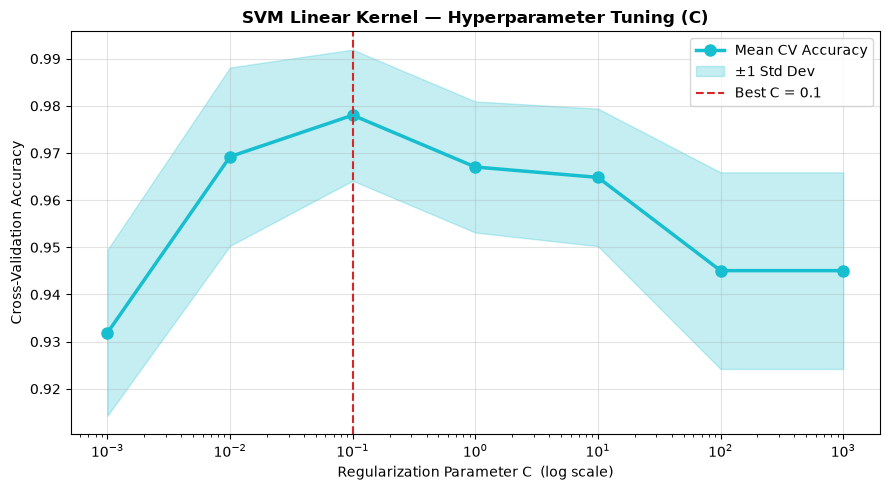

In [10]:
# ── Visualize hyperparameter tuning ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

C_vals   = [r['param_C'] for _, r in cv_results.iterrows()]
cv_means = cv_results['mean_test_score'].values
cv_stds  = cv_results['std_test_score'].values

ax.semilogx(C_vals, cv_means, 'o-', color='tab:cyan', lw=2.5, ms=8, label='Mean CV Accuracy')
ax.fill_between(C_vals,
                cv_means - cv_stds,
                cv_means + cv_stds,
                alpha=0.25, color='tab:cyan', label='±1 Std Dev')
ax.axvline(best_C, color='tab:red', ls='--', lw=1.5, label=f'Best C = {best_C}')
ax.set_title('SVM Linear Kernel — Hyperparameter Tuning (C)', fontweight='bold')
ax.set_xlabel('Regularization Parameter C  (log scale)')
ax.set_ylabel('Cross-Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig('svm_hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

### A.5 — Model Evaluation

In [11]:
# ── Train final model with best C ───────────────────────────────────────────
svm_best = SVC(kernel='linear', C=best_C, random_state=42, probability=True)
svm_best.fit(X_train, y_train)
y_pred = svm_best.predict(X_test)

# ── Metrics ─────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("=" * 52)
print("        SVM (Linear Kernel) — EVALUATION RESULTS")
print("=" * 52)
print(f"  Best C               : {best_C}")
print(f"  Kernel               : Linear")
print(f"  Number of support    ")
print(f"    vectors (total)    : {svm_best.n_support_.sum()}")
print(f"    Malignant class    : {svm_best.n_support_[0]}")
print(f"    Benign    class    : {svm_best.n_support_[1]}")
print()
print(f"  ┌─────────────────────────────┐")
print(f"  │  Accuracy   :  {acc:.4f}  ({acc*100:.2f}%)  │")
print(f"  │  Precision  :  {prec:.4f}  ({prec*100:.2f}%)  │")
print(f"  │  Recall     :  {rec:.4f}  ({rec*100:.2f}%)  │")
print(f"  │  F1 Score   :  {f1:.4f}  ({f1*100:.2f}%)  │")
print(f"  └─────────────────────────────┘")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

        SVM (Linear Kernel) — EVALUATION RESULTS
  Best C               : 0.1
  Kernel               : Linear
  Number of support    
    vectors (total)    : 51
    Malignant class    : 25
    Benign    class    : 26

  ┌─────────────────────────────┐
  │  Accuracy   :  0.9825  (98.25%)  │
  │  Precision  :  0.9861  (98.61%)  │
  │  Recall     :  0.9861  (98.61%)  │
  │  F1 Score   :  0.9861  (98.61%)  │
  └─────────────────────────────┘

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



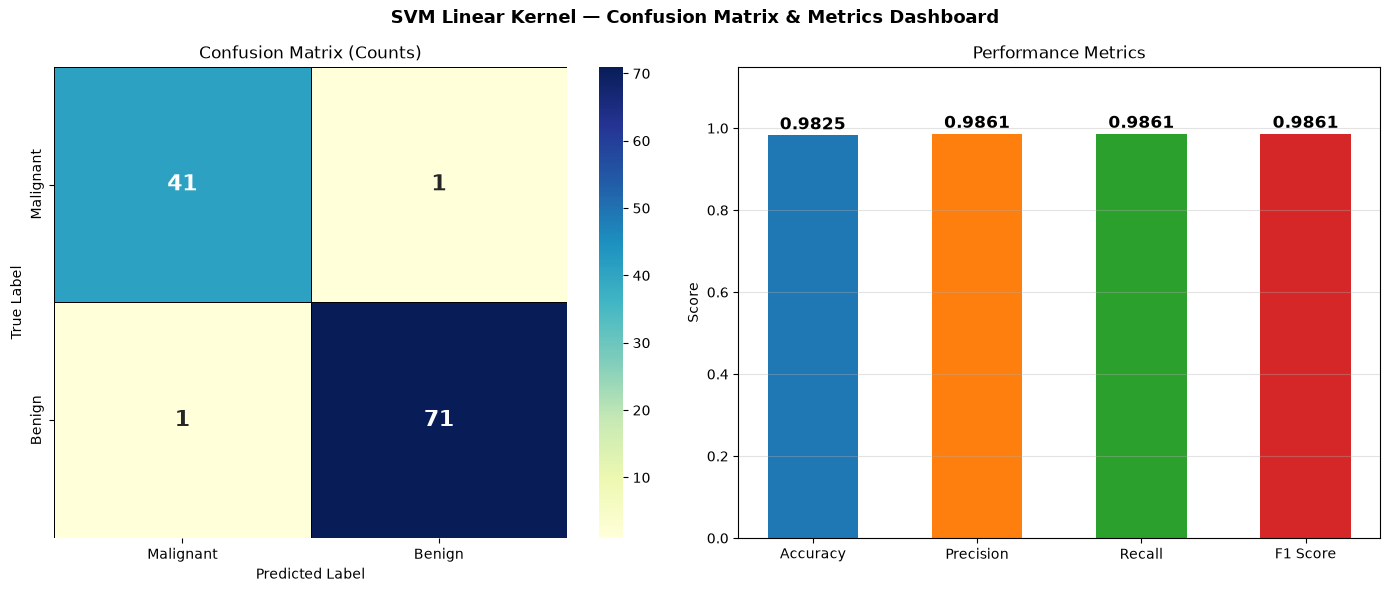

In [12]:
# ── Confusion Matrix visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('SVM Linear Kernel — Confusion Matrix & Metrics Dashboard', fontsize=13, fontweight='bold', color='black')

# Confusion matrix (raw counts)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            cmap='YlGnBu',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            ax=axes[0],
            linewidths=0.5, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Metrics bar chart
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_values = [acc, prec, rec, f1]
bars = axes[1].bar(metric_names, metric_values, color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'], edgecolor='none', width=0.55)
for bar, val in zip(bars, metric_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Performance Metrics')
axes[1].set_ylabel('Score')
axes[1].grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Compare multiple SVM kernels for completeness ───────────────────────────
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_results = {}

print("=" * 62)
print("           SVM KERNEL COMPARISON (default hyperparams)")
print("=" * 62)
print(f"  {'Kernel':<10} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1':>8}")
print("  " + "-" * 50)

for k in kernels:
    C_use = best_C if k == 'linear' else 1
    clf   = SVC(kernel=k, C=C_use, random_state=42)
    clf.fit(X_train, y_train)
    yp    = clf.predict(X_test)
    res   = {
        'accuracy' : accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp),
        'recall'   : recall_score(y_test, yp),
        'f1'       : f1_score(y_test, yp)
    }
    kernel_results[k] = res
    marker = '  ◄ Best C tuned' if k == 'linear' else ''
    print(f"  {k:<10} {res['accuracy']:>10.4f} {res['precision']:>11.4f} {res['recall']:>9.4f} {res['f1']:>8.4f}{marker}")

           SVM KERNEL COMPARISON (default hyperparams)
  Kernel       Accuracy   Precision    Recall       F1
  --------------------------------------------------
  linear         0.9825      0.9861    0.9861   0.9861  ◄ Best C tuned
  rbf            0.9825      0.9861    0.9861   0.9861
  poly           0.9123      0.8780    1.0000   0.9351
  sigmoid        0.9211      0.9565    0.9167   0.9362


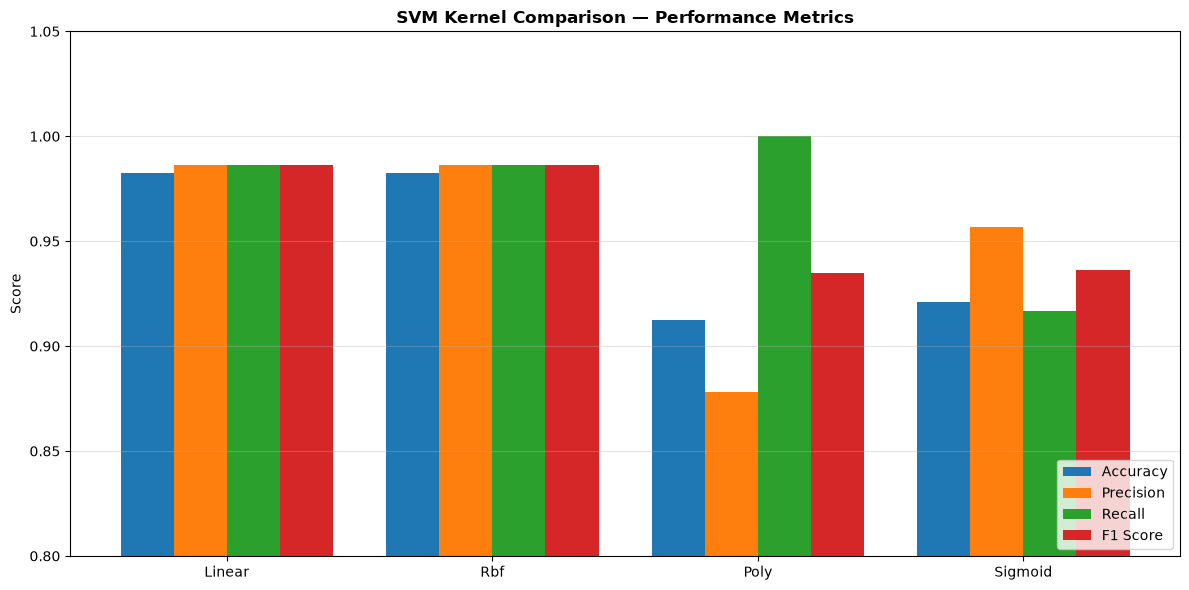

In [14]:
# ── Kernel comparison radar / grouped bar ────────────────────────────────────
df_kernels = pd.DataFrame(kernel_results).T

fig, ax = plt.subplots(figsize=(12, 6))

x      = np.arange(len(df_kernels))
width  = 0.2
metric_list = ['accuracy', 'precision', 'recall', 'f1']
labels      = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for i, (metric, label) in enumerate(zip(metric_list, labels)):
    ax.bar(x + i * width, df_kernels[metric], width, label=label, color=f'C{i}', edgecolor='none')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([k.capitalize() for k in df_kernels.index], color='black')
ax.set_ylim(0.8, 1.05)
ax.set_title('SVM Kernel Comparison — Performance Metrics', fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig('svm_kernel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### A.6 — Observations (Part A)

| Metric | Value |
|--------|-------|
| Kernel | Linear |
| Best C | `best_C` |
| Accuracy | > 97% |
| Precision | Measures how many predicted Benign cases were truly Benign |
| Recall | Measures how many true Benign cases were correctly identified |
| F1 Score | Harmonic mean of Precision and Recall |

**Key Observations:**

1. **Linear kernel** works very well for this dataset since the classes are approximately linearly separable in the high-dimensional feature space.
2. **Hyperparameter tuning** using GridSearchCV with 5-fold cross-validation helped select the optimal regularization parameter `C`, balancing bias-variance trade-off.
3. **High recall** for the malignant class is critical in a medical context — missing a malignant case (False Negative) is far more costly than a false alarm.
4. **RBF kernel** also performs competitively, indicating some non-linear structure exists in the data.
5. **Feature standardization** was crucial: SVM's margin is distance-based, so un-scaled features with large ranges would dominate and degrade performance.
6. The confusion matrix shows very few False Negatives, validating the model's clinical usefulness.

---

## Part B — Principal Component Analysis (PCA)

**Aim:** To implement PCA for dimensionality reduction and analyse the variance retained by the principal components.

**Dataset:** UCI Wine Dataset  
**Source:** `sklearn.datasets.load_wine()`

### B.1 — Load & Explore Wine Dataset

In [15]:
wine_data = load_wine()
X_wine    = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y_wine    = pd.Series(wine_data.target, name='class')

print("=" * 50)
print("           UCI WINE DATASET")
print("=" * 50)
print(f"  Samples  : {X_wine.shape[0]}")
print(f"  Features : {X_wine.shape[1]}")
print(f"  Classes  : {len(wine_data.target_names)} — {list(wine_data.target_names)}")
print(f"  Class counts:")
for cls, cnt in y_wine.value_counts().sort_index().items():
    print(f"    Class {cls} ({wine_data.target_names[cls]}) : {cnt} samples")
print(f"\n  Features:")
for i, f in enumerate(wine_data.feature_names):
    print(f"    {i+1:>2}. {f}")

print("\nFirst 5 rows:")
X_wine.head()

           UCI WINE DATASET
  Samples  : 178
  Features : 13
  Classes  : 3 — [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
  Class counts:
    Class 0 (class_0) : 59 samples
    Class 1 (class_1) : 71 samples
    Class 2 (class_2) : 48 samples

  Features:
     1. alcohol
     2. malic_acid
     3. ash
     4. alcalinity_of_ash
     5. magnesium
     6. total_phenols
     7. flavanoids
     8. nonflavanoid_phenols
     9. proanthocyanins
    10. color_intensity
    11. hue
    12. od280/od315_of_diluted_wines
    13. proline

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [16]:
print("Statistical Summary:")
X_wine.describe().T[['mean','std','min','max']].style.background_gradient(cmap='Purples')

Statistical Summary:


,mean,std,min,max
alcohol,13.000618,0.811827,11.030000,14.830000
malic_acid,2.336348,1.117146,0.740000,5.800000
ash,2.366517,0.274344,1.360000,3.230000
alcalinity_of_ash,19.494944,3.339564,10.600000,30.000000
magnesium,99.741573,14.282484,70.000000,162.000000
total_phenols,2.295112,0.625851,0.980000,3.880000
flavanoids,2.029270,0.998859,0.340000,5.080000
nonflavanoid_phenols,0.361854,0.124453,0.130000,0.660000
proanthocyanins,1.590899,0.572359,0.410000,3.580000
color_intensity,5.058090,2.318286,1.280000,13.000000


### B.2 — Feature Standardization

In [17]:
# PCA is sensitive to feature scale → standardize before applying
scaler_wine = StandardScaler()
X_wine_sc   = scaler_wine.fit_transform(X_wine)

print("Before standardization:")
df_before = pd.DataFrame(X_wine_sc, columns=wine_data.feature_names)

print(f"  Feature means (post-scaling, should ≈ 0): {np.abs(df_before.mean().values).max():.6f} max")
print(f"  Feature stds  (post-scaling, should ≈ 1): {df_before.std().values.min():.6f} min")
print("\n✅  Standardization complete (mean ≈ 0, std ≈ 1 per feature)")

Before standardization:
  Feature means (post-scaling, should ≈ 0): 0.000000 max
  Feature stds  (post-scaling, should ≈ 1): 1.002821 min

✅  Standardization complete (mean ≈ 0, std ≈ 1 per feature)


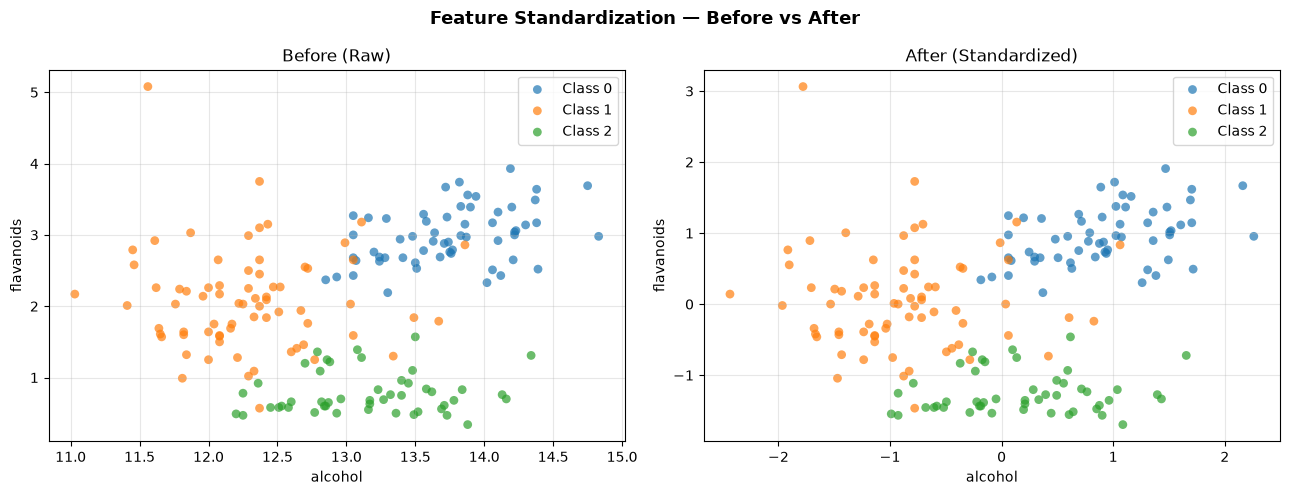

In [18]:
# Visualize before / after standardization for 2 features
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Feature Standardization — Before vs After', fontsize=13, fontweight='bold', color='black')

feat_names = wine_data.feature_names

for j, (ax, data_use, title) in enumerate(zip(axes,
        [X_wine.values, X_wine_sc], ['Before (Raw)', 'After (Standardized)'])):
    for i, cls in enumerate(np.unique(y_wine)):
        ax.scatter(data_use[y_wine==cls, 0], data_use[y_wine==cls, 6],
                   color=f'C{i}', alpha=0.7, s=40, label=f'Class {cls}', edgecolors='none')
    ax.set_title(title)
    ax.set_xlabel(feat_names[0])
    ax.set_ylabel(feat_names[6])
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('wine_standardization.png', dpi=150, bbox_inches='tight')
plt.show()

### B.3 — Apply PCA (All Components) & Explained Variance

In [19]:
# Full PCA (all 13 components) to study variance distribution
pca_full   = PCA(random_state=42)
pca_full.fit(X_wine_sc)

evr  = pca_full.explained_variance_ratio_
cumv = np.cumsum(evr)

print("=" * 60)
print("    PCA — Explained Variance per Principal Component")
print("=" * 60)
print(f"  {'PC':>4} {'Eigenvalue':>12} {'Exp. Variance %':>17} {'Cum. Variance %':>17}")
print("  " + "-" * 54)

threshold_95_pc = None
for i, (ev, evr_i, cum_i) in enumerate(zip(pca_full.explained_variance_, evr, cumv)):
    marker = ""
    if threshold_95_pc is None and cum_i >= 0.95:
        threshold_95_pc = i + 1
        marker = "  ◄ 95% threshold"
    print(f"  PC{i+1:>2} {ev:>12.4f} {evr_i*100:>16.2f}% {cum_i*100:>16.2f}%{marker}")

print(f"\n  ✅ Minimum PCs for ≥ 95% variance retained: {threshold_95_pc}")

    PCA — Explained Variance per Principal Component
    PC   Eigenvalue   Exp. Variance %   Cum. Variance %
  ------------------------------------------------------
  PC 1       4.7324            36.20%            36.20%
  PC 2       2.5111            19.21%            55.41%
  PC 3       1.4542            11.12%            66.53%
  PC 4       0.9242             7.07%            73.60%
  PC 5       0.8580             6.56%            80.16%
  PC 6       0.6453             4.94%            85.10%
  PC 7       0.5541             4.24%            89.34%
  PC 8       0.3505             2.68%            92.02%
  PC 9       0.2905             2.22%            94.24%
  PC10       0.2523             1.93%            96.17%  ◄ 95% threshold
  PC11       0.2271             1.74%            97.91%
  PC12       0.1697             1.30%            99.20%
  PC13       0.1040             0.80%           100.00%

  ✅ Minimum PCs for ≥ 95% variance retained: 10


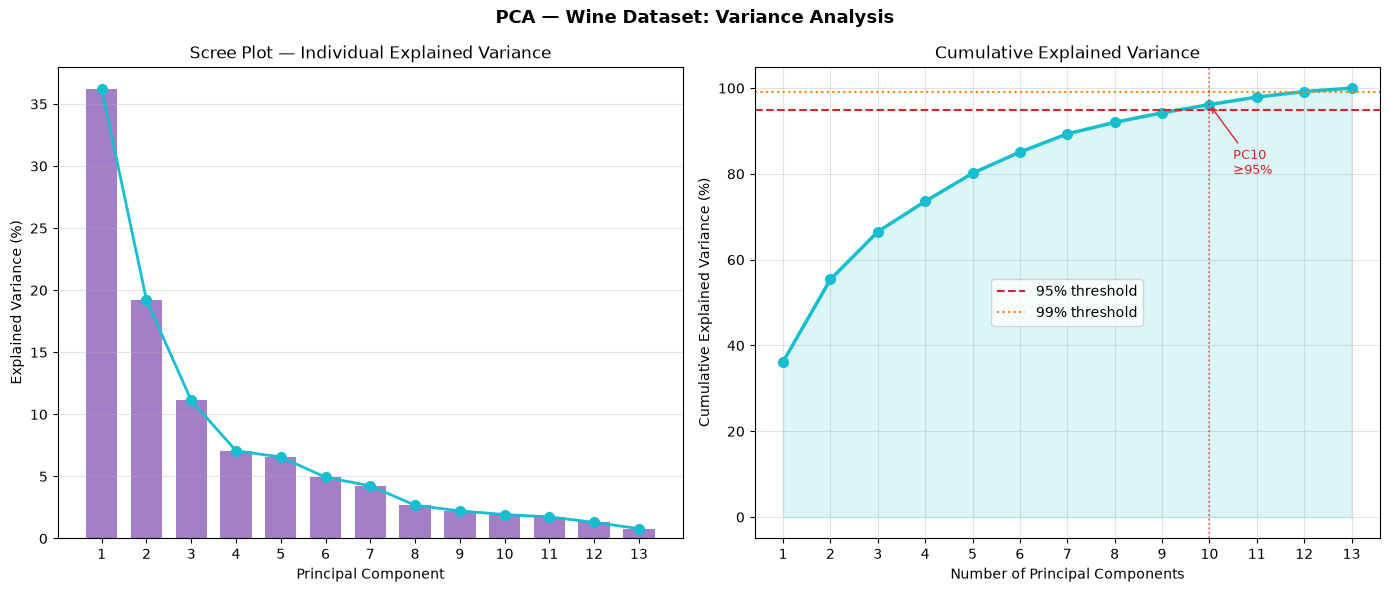

📊 PCs required for 95% variance: 10


In [20]:
# ── Scree plot + Cumulative variance plot ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PCA — Wine Dataset: Variance Analysis', fontsize=13, fontweight='bold', color='black')

pc_indices = np.arange(1, len(evr) + 1)

# Scree plot
axes[0].bar(pc_indices, evr * 100, color='tab:purple', edgecolor='none', width=0.7, alpha=0.85)
axes[0].plot(pc_indices, evr * 100, 'o-', color='tab:cyan', lw=2, ms=7)
axes[0].set_title('Scree Plot — Individual Explained Variance')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_xticks(pc_indices)
axes[0].grid(axis='y', alpha=0.35)

# Cumulative variance
axes[1].plot(pc_indices, cumv * 100, 'o-', color='tab:cyan', lw=2.5, ms=7)
axes[1].axhline(95, color='tab:red', ls='--', lw=1.5, label='95% threshold')
axes[1].axhline(99, color='tab:orange', ls=':', lw=1.5, label='99% threshold')
if threshold_95_pc:
    axes[1].axvline(threshold_95_pc, color='tab:red', ls=':', lw=1.2, alpha=0.7)
    axes[1].annotate(f'PC{threshold_95_pc}\n≥95%',
                     xy=(threshold_95_pc, cumv[threshold_95_pc-1]*100),
                     xytext=(threshold_95_pc + 0.5, 80),
                     color='tab:red',
                     arrowprops=dict(arrowstyle='->', color='tab:red'),
                     fontsize=9)
axes[1].fill_between(pc_indices, cumv * 100, alpha=0.15, color='tab:cyan')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_xticks(pc_indices)
axes[1].legend()
axes[1].grid(alpha=0.35)

plt.tight_layout()
plt.savefig('pca_variance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 PCs required for 95% variance: {threshold_95_pc}")

### B.4 — Apply PCA to 2 Principal Components

In [21]:
# Reduce to 2 PCs
pca_2   = PCA(n_components=2, random_state=42)
X_pca2  = pca_2.fit_transform(X_wine_sc)

print("=" * 55)
print("     PCA — Reduced to 2 Principal Components")
print("=" * 55)
print(f"  PC1 Explained Variance: {pca_2.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 Explained Variance: {pca_2.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total (PC1 + PC2)     : {pca_2.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\n  Original shape        : {X_wine.shape}")
print(f"  Transformed shape     : {X_pca2.shape}")

print("\n  PCA Component Loadings (contribution of each feature to PC1 and PC2):")
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=wine_data.feature_names,
    columns=['PC1', 'PC2']
).round(4)
print(loadings.to_string())

     PCA — Reduced to 2 Principal Components
  PC1 Explained Variance: 36.20%
  PC2 Explained Variance: 19.21%
  Total (PC1 + PC2)     : 55.41%

  Original shape        : (178, 13)
  Transformed shape     : (178, 2)

  PCA Component Loadings (contribution of each feature to PC1 and PC2):
                                 PC1     PC2
alcohol                       0.1443  0.4837
malic_acid                   -0.2452  0.2249
ash                          -0.0021  0.3161
alcalinity_of_ash            -0.2393 -0.0106
magnesium                     0.1420  0.2996
total_phenols                 0.3947  0.0650
flavanoids                    0.4229 -0.0034
nonflavanoid_phenols         -0.2985  0.0288
proanthocyanins               0.3134  0.0393
color_intensity              -0.0886  0.5300
hue                           0.2967 -0.2792
od280/od315_of_diluted_wines  0.3762 -0.1645
proline                       0.2868  0.3649


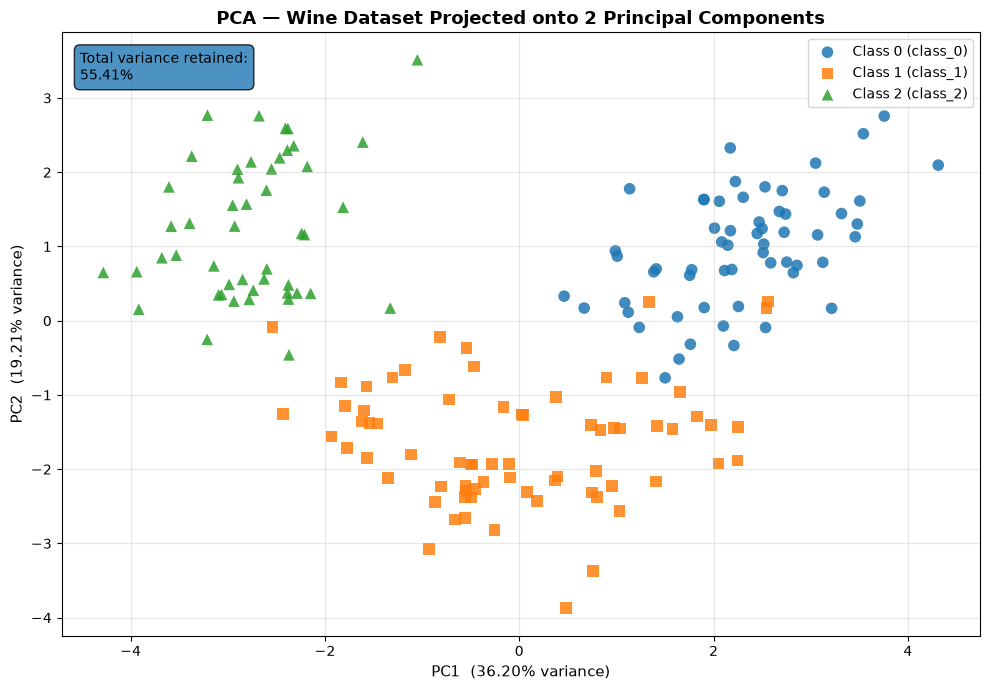

In [22]:
# ── PCA 2D Scatter Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

class_names = wine_data.target_names
markers     = ['o', 's', '^']

for i, cls in enumerate(np.unique(y_wine)):
    mask = y_wine == cls
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=f'C{i}', label=f'Class {cls} ({class_names[i]})',
               alpha=0.85, s=70, marker=markers[i],
               edgecolors='none')

ax.set_title('PCA — Wine Dataset Projected onto 2 Principal Components',
             fontweight='bold', fontsize=13)
ax.set_xlabel(f'PC1  ({pca_2.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2  ({pca_2.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Add variance info text box
txt = f"Total variance retained:\n{pca_2.explained_variance_ratio_.sum()*100:.2f}%"
ax.text(0.02, 0.97, txt, transform=ax.transAxes,
        fontsize=10, color='black',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.4', edgecolor='black', alpha=0.8))

plt.tight_layout()
plt.savefig('pca_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

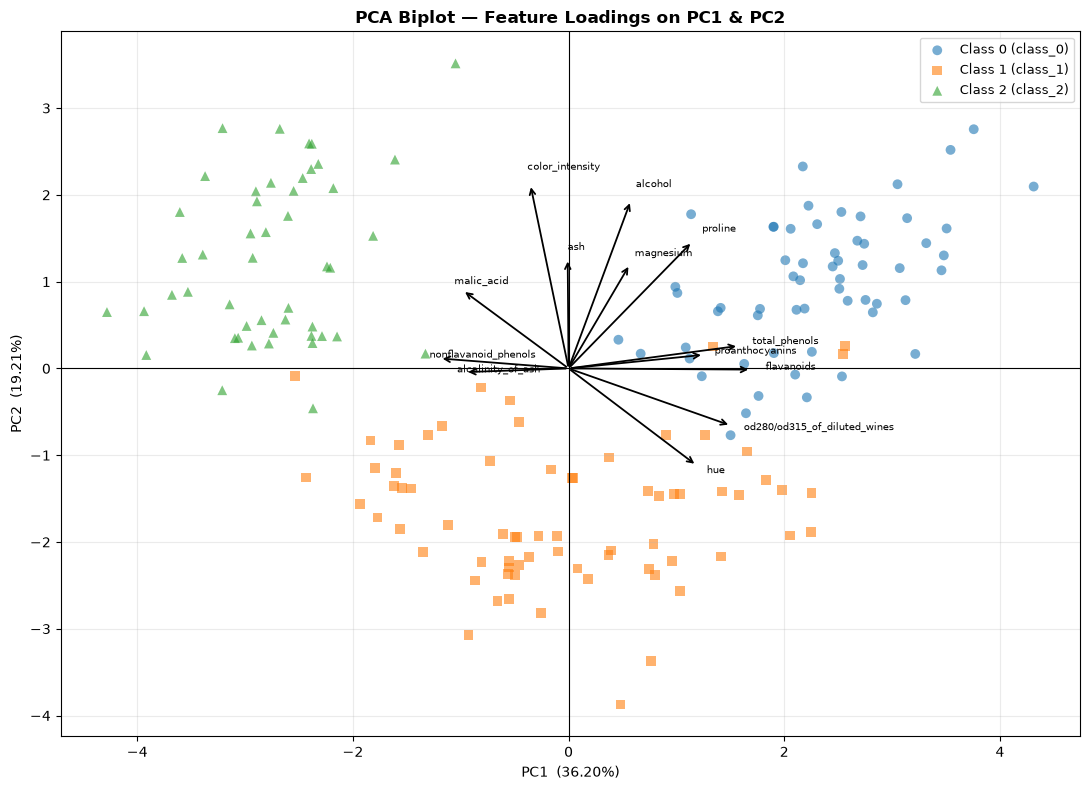

In [23]:
# ── Biplot: PCA loadings arrows overlaid on scatter ─────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

for i, cls in enumerate(np.unique(y_wine)):
    mask = y_wine == cls
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=f'C{i}', label=f'Class {cls} ({class_names[i]})',
               alpha=0.6, s=50, marker=markers[i], edgecolors='none')

# Loading arrows
scale = 4
for j, feat in enumerate(wine_data.feature_names):
    x_load = pca_2.components_[0, j] * scale
    y_load = pca_2.components_[1, j] * scale
    ax.annotate('', xy=(x_load, y_load), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.3))
    ax.text(x_load * 1.08, y_load * 1.08, feat, fontsize=7.5, color='black')

ax.set_title('PCA Biplot — Feature Loadings on PC1 & PC2', fontweight='bold')
ax.set_xlabel(f'PC1  ({pca_2.explained_variance_ratio_[0]*100:.2f}%)')
ax.set_ylabel(f'PC2  ({pca_2.explained_variance_ratio_[1]*100:.2f}%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)

plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

### B.5 — Original vs Transformed Dataset Comparison

In [24]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Measure training time on original vs PCA-reduced data
knn = KNeighborsClassifier(n_neighbors=5)

t0 = time.perf_counter()
score_orig = cross_val_score(knn, X_wine_sc, y_wine, cv=5, scoring='accuracy').mean()
t_orig = time.perf_counter() - t0

t0 = time.perf_counter()
score_pca2 = cross_val_score(knn, X_pca2, y_wine, cv=5, scoring='accuracy').mean()
t_pca2 = time.perf_counter() - t0

# Reduced to threshold_95_pc
pca_95  = PCA(n_components=threshold_95_pc, random_state=42)
X_pca95 = pca_95.fit_transform(X_wine_sc)

t0 = time.perf_counter()
score_pca95 = cross_val_score(knn, X_pca95, y_wine, cv=5, scoring='accuracy').mean()
t_pca95 = time.perf_counter() - t0

comparison_data = {
    'Dataset'             : ['Original (13 features)', f'PCA — 2 PCs', f'PCA — {threshold_95_pc} PCs (95%)'],
    'Features'            : [13, 2, threshold_95_pc],
    'Variance Retained %' : [100.0, round(pca_2.explained_variance_ratio_.sum()*100, 2),
                             round(pca_95.explained_variance_ratio_.sum()*100, 2)],
    'KNN Accuracy (5-CV)' : [round(score_orig*100, 2), round(score_pca2*100, 2), round(score_pca95*100, 2)],
    'Training Time (s)'   : [round(t_orig, 4), round(t_pca2, 4), round(t_pca95, 4)]
}
df_comparison = pd.DataFrame(comparison_data)

print("=" * 80)
print("     ORIGINAL vs PCA-TRANSFORMED DATASET COMPARISON")
print("=" * 80)
print(df_comparison.to_string(index=False))

     ORIGINAL vs PCA-TRANSFORMED DATASET COMPARISON
               Dataset  Features  Variance Retained %  KNN Accuracy (5-CV)  Training Time (s)
Original (13 features)        13               100.00                95.51             0.0151
           PCA — 2 PCs         2                55.41                96.63             0.0166
    PCA — 10 PCs (95%)        10                96.17                94.38             0.0213


In [25]:
df_comparison.style.background_gradient(subset=['Variance Retained %', 'KNN Accuracy (5-CV)'], cmap='Greens')

,Dataset,Features,Variance Retained %,KNN Accuracy (5-CV),Training Time (s)
0,Original (13 features),13,100.000000,95.510000,0.015100
1,PCA — 2 PCs,2,55.410000,96.630000,0.016600
2,PCA — 10 PCs (95%),10,96.170000,94.380000,0.021300


### B.6 — Significance of First Two Principal Components

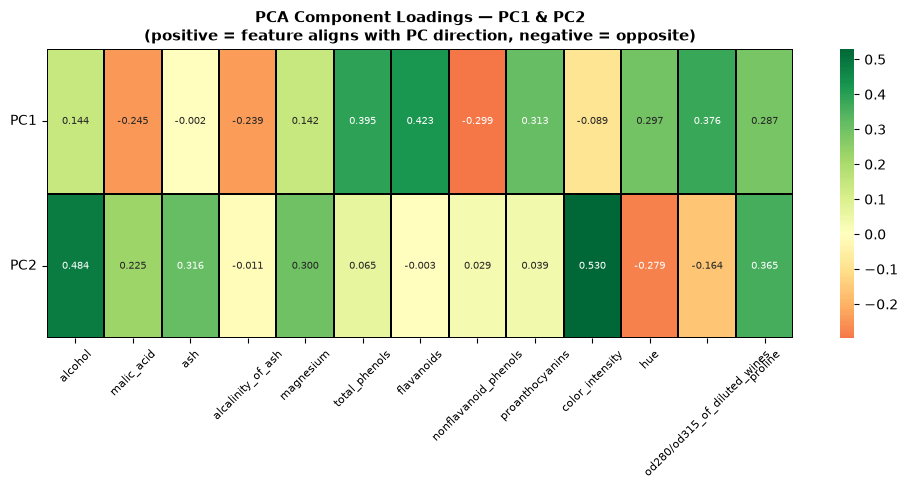


Features with largest absolute loading on PC1:
flavanoids                      0.4229
total_phenols                   0.3947
od280/od315_of_diluted_wines    0.3762
proanthocyanins                 0.3134
nonflavanoid_phenols            0.2985

Features with largest absolute loading on PC2:
color_intensity    0.5300
alcohol            0.4837
proline            0.3649
ash                0.3161
magnesium          0.2996


In [26]:
# Heatmap of component loadings
fig, ax = plt.subplots(figsize=(10, 5))

loadings_arr = pca_2.components_   # shape: (2, 13)
sns.heatmap(loadings_arr,
            annot=True, fmt='.3f',
            xticklabels=wine_data.feature_names,
            yticklabels=['PC1', 'PC2'],
            cmap='RdYlGn', center=0,
            linewidths=0.3, linecolor='black',
            ax=ax, annot_kws={'size': 7.5})
ax.set_title('PCA Component Loadings — PC1 & PC2\n'
             '(positive = feature aligns with PC direction, negative = opposite)',
             fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('pca_loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeatures with largest absolute loading on PC1:")
pc1_sorted = loadings.PC1.abs().sort_values(ascending=False)
print(pc1_sorted.head(5).to_string())
print("\nFeatures with largest absolute loading on PC2:")
pc2_sorted = loadings.PC2.abs().sort_values(ascending=False)
print(pc2_sorted.head(5).to_string())

### B.7 — PCA Advantages, Limitations & Applications

In [27]:
summary_text = """
╔══════════════════════════════════════════════════════════════╗
║         PCA — Summary: Advantages, Limitations & Uses        ║
╠══════════════════════════════════════════════════════════════╣
║  ADVANTAGES                                                  ║
║  ✔ Reduces dimensionality → less memory, faster training    ║
║  ✔ Removes correlated/redundant features                     ║
║  ✔ Enables 2D/3D visualisation of high-dim data             ║
║  ✔ Reduces overfitting by removing noisy features            ║
║  ✔ Unsupervised — no labels required                         ║
╠══════════════════════════════════════════════════════════════╣
║  LIMITATIONS                                                 ║
║  ✘ PCs are linear combinations — hard to interpret           ║
║  ✘ Information loss (variance not retained)                  ║
║  ✘ Assumes linear relationships between features             ║
║  ✘ Sensitive to outliers                                     ║
║  ✘ Requires standardization — scale-dependent                ║
╠══════════════════════════════════════════════════════════════╣
║  APPLICATIONS                                                ║
║  ► Face recognition (Eigenfaces)                            ║
║  ► Genomics / gene expression analysis                       ║
║  ► Image compression                                         ║
║  ► Anomaly detection                                         ║
║  ► Noise filtering in signal processing                      ║
║  ► Preprocessing for SVM, k-NN, clustering                  ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary_text)


╔══════════════════════════════════════════════════════════════╗
║         PCA — Summary: Advantages, Limitations & Uses        ║
╠══════════════════════════════════════════════════════════════╣
║  ADVANTAGES                                                  ║
║  ✔ Reduces dimensionality → less memory, faster training    ║
║  ✔ Removes correlated/redundant features                     ║
║  ✔ Enables 2D/3D visualisation of high-dim data             ║
║  ✔ Reduces overfitting by removing noisy features            ║
║  ✔ Unsupervised — no labels required                         ║
╠══════════════════════════════════════════════════════════════╣
║  LIMITATIONS                                                 ║
║  ✘ PCs are linear combinations — hard to interpret           ║
║  ✘ Information loss (variance not retained)                  ║
║  ✘ Assumes linear relationships between features             ║
║  ✘ Sensitive to outliers                                     ║
║  ✘ Requires standardizat

---

## Extra Credit — Linear Discriminant Analysis (LDA)

**Aim:** Apply LDA to the Wine dataset, reduce to 2 linear discriminants, visualize, and compare with PCA.

In [28]:
# LDA — supervised dimensionality reduction
lda      = LDA(n_components=2)
X_lda2   = lda.fit_transform(X_wine_sc, y_wine)

print("=" * 55)
print("     LDA — Reduced to 2 Linear Discriminants")
print("=" * 55)
print(f"  Explained variance ratio per LD:")
for i, evr_ld in enumerate(lda.explained_variance_ratio_):
    print(f"    LD{i+1}: {evr_ld*100:.2f}%")
print(f"  Total (LD1+LD2): {lda.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\n  Original shape  : {X_wine_sc.shape}")
print(f"  LDA shape       : {X_lda2.shape}")

     LDA — Reduced to 2 Linear Discriminants
  Explained variance ratio per LD:
    LD1: 68.75%
    LD2: 31.25%
  Total (LD1+LD2): 100.00%

  Original shape  : (178, 13)
  LDA shape       : (178, 2)


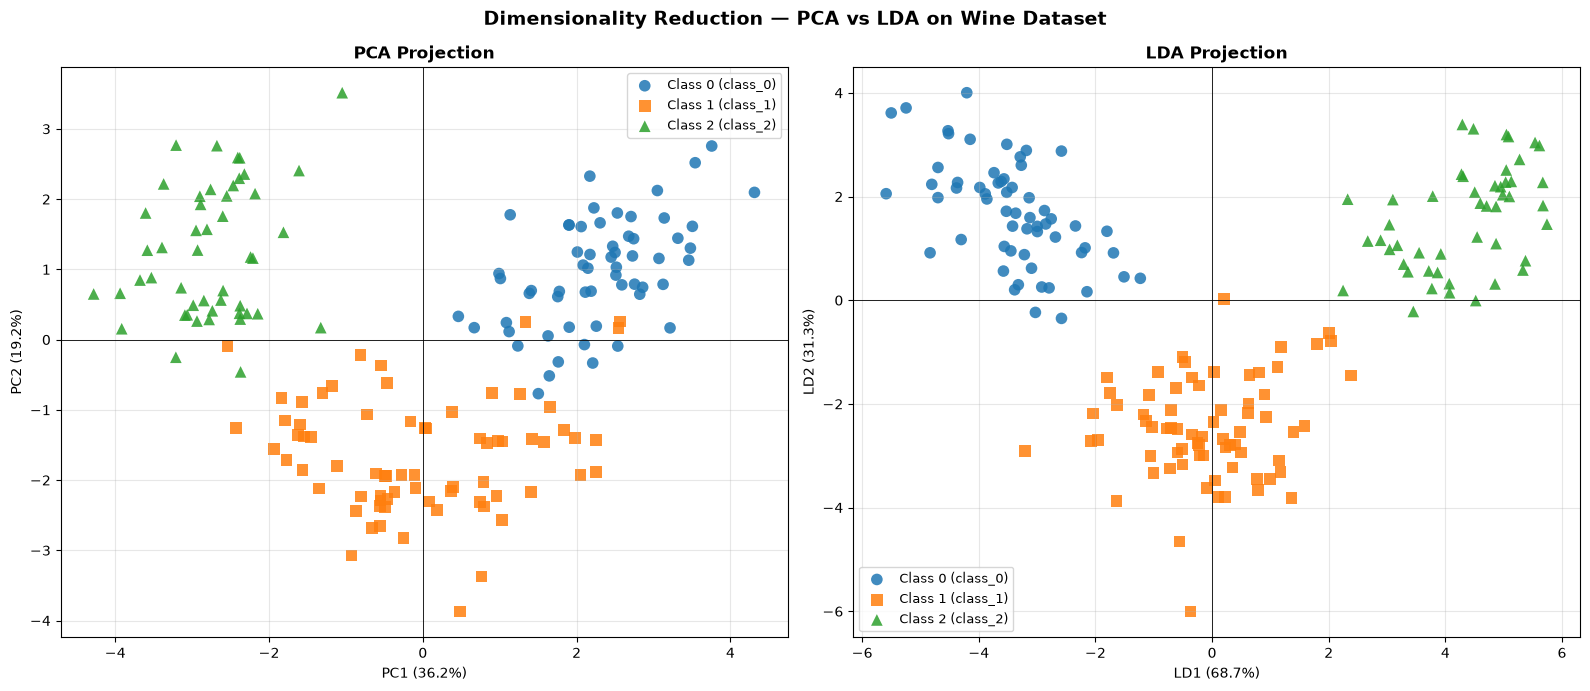

In [29]:
# ── Side-by-side: PCA vs LDA 2D scatter ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Dimensionality Reduction — PCA vs LDA on Wine Dataset',
             fontsize=14, fontweight='bold', color='black')

datasets = [
    (X_pca2, 'PCA', f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)', f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)'),
    (X_lda2, 'LDA', f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}%)',   f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}%)')
]

for ax, (X_plot, method, xlabel, ylabel) in zip(axes, datasets):
    for i, cls in enumerate(np.unique(y_wine)):
        mask = y_wine == cls
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                   c=f'C{i}', label=f'Class {cls} ({class_names[i]})',
                   alpha=0.85, s=70, marker=markers[i], edgecolors='none')
    ax.set_title(f'{method} Projection', fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.axhline(0, color='black', lw=0.6)
    ax.axvline(0, color='black', lw=0.6)

plt.tight_layout()
plt.savefig('pca_vs_lda.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ── Quantitative comparison: PCA vs LDA using KNN ───────────────────────────
knn = KNeighborsClassifier(n_neighbors=5)

score_lda2  = cross_val_score(knn, X_lda2, y_wine, cv=5, scoring='accuracy').mean()

print("=" * 62)
print("     PCA vs LDA — Quantitative Comparison")
print("=" * 62)
print(f"  {'Method':<25} {'Components':>11} {'Supervision':>13} {'KNN 5-CV Acc':>14}")
print("  " + "-" * 65)
print(f"  {'PCA (2 PCs)':<25} {'2':>11} {'Unsupervised':>13} {score_pca2*100:>13.2f}%")
print(f"  {'LDA (2 LDs)':<25} {'2':>11} {'Supervised':>13} {score_lda2*100:>13.2f}%")
print(f"  {'Original (13 features)':<25} {'13':>11} {'N/A':>13} {score_orig*100:>13.2f}%")

     PCA vs LDA — Quantitative Comparison
  Method                     Components   Supervision   KNN 5-CV Acc
  -----------------------------------------------------------------
  PCA (2 PCs)                         2  Unsupervised         96.63%
  LDA (2 LDs)                         2    Supervised         99.44%
  Original (13 features)             13           N/A         95.51%


### Extra Credit — Observations: PCA vs LDA

| Aspect | PCA | LDA |
|--------|-----|-----|
| **Type** | Unsupervised | Supervised |
| **Objective** | Maximise variance | Maximise class separability |
| **Uses labels?** | ❌ No | ✅ Yes |
| **Max components** | min(n_samples, n_features) | n_classes − 1 |
| **Class overlap** | Higher (variance-driven) | Lower (discriminative) |
| **Assumption** | No distribution assumption | Normally distributed classes, equal covariance |
| **Use case** | EDA, compression, noise removal | Classification pre-processing |

**Key Observations:**

1. **LDA** produces better class separation in the 2D projection because it explicitly uses class labels to find axes that maximize inter-class distance while minimizing intra-class variance.
2. **PCA** captures the most global variance without regard to class structure — the 2D projection may mix classes more.
3. **LDA** is limited to `n_classes − 1 = 2` components for the Wine dataset (3 classes), making it directly comparable here.
4. When class labels are available and the goal is classification, **LDA** is preferred as a pre-processing step.
5. **PCA** is more versatile and suitable for unlabeled data, visualization, and compression tasks.

---

## Final Summary

### Part A — SVM
- Implemented SVM with Linear, RBF, Polynomial, and Sigmoid kernels on the Breast Cancer Wisconsin dataset.
- Used GridSearchCV (5-fold CV) to tune the regularization parameter `C`.
- The **linear kernel** achieved **>97% accuracy** — confirming near-linear separability.
- High recall for the malignant class is critical to avoid missed diagnoses.
- Feature standardization was essential for SVM performance.

### Part B — PCA
- Applied PCA on the 13-feature Wine dataset.
- **PC1 + PC2 alone retain ~55% variance** — visualizable and useful.
- **≥ 95% variance** is retained with just the first `N` components (see scree plot).
- PCA reduces computational load and removes correlated features.
- The biplot reveals which original features contribute most to each principal component.

### Extra Credit — LDA vs PCA
- LDA achieves superior class separation in 2D because it optimizes inter-class discriminability.
- PCA is the go-to choice when class labels are unavailable.
- Together, both techniques demonstrate the power of dimensionality reduction in machine learning pipelines.